## Validation against tidal gauge data

Contains comparision of model output with tidal gauge data by calculating metrics and visualizing water level.

In [1]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import metrics
from modules import read_files as read
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

### Configuration

In [2]:
run_name = 'validation'                                     # set run name for output
rugosity = 0.0025                                       # set value used for calibration parameter
output_file = '../../results/validation/water_level/water_level_metrics.xlsx'

# period
start_date = '2023-04-13T00'
end_date = '2023-05-31T00'

# model output
dir_model_output = '../../data/model_output'
folder_name = 'L2'
layer = 1
base_name = 'tide_gauge_Gomera_validation' 

# tidal gauge data
dir_gauge = '../../data/tide_gauge/26657_55767_3463_SEA_LEVEL_20230413105914_20230602105914.csv'

### Reading files

In [3]:
# model output
all_results = read.read_files(base_dir=dir_model_output, folder=folder_name, name=base_name)
model_wl = all_results[layer]['water_level'].loc[start_date:end_date]
model_wl = model_wl.to_frame(name="water_level")
model_wl.index = pd.to_datetime(model_wl.index)

# tidal gauge
gauge_wl = pd.read_csv(
    dir_gauge,
    sep="\t",          # Tab-separated
    skiprows=1,        # Skip the metadata line
    na_values=-9999.9, # Convert the null value to NaN
    encoding="utf-8"
)

gauge_wl['date'] = pd.to_datetime(gauge_wl['Fecha (GMT)']) 
gauge_wl['water_level'] = gauge_wl['Nivel (cm)'] / 100
gauge_wl = gauge_wl[['date', 'water_level']]
gauge_wl.set_index('date', inplace=True)
gauge_wl = gauge_wl.loc[start_date:end_date]

### Comparision

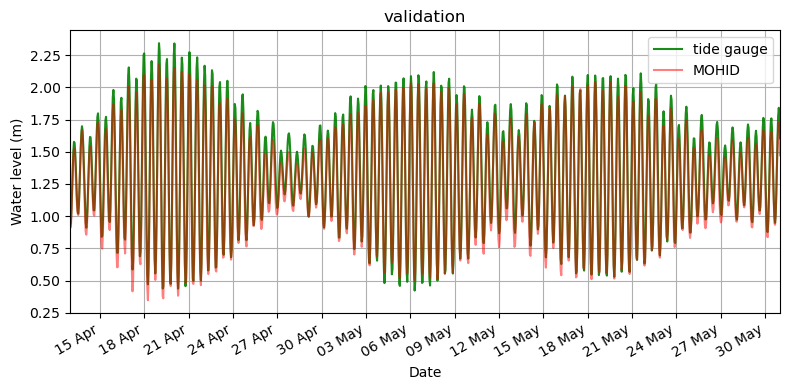

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    gauge_wl.index,
    gauge_wl["water_level"],
    label="tide gauge",
    alpha=0.9,
    color='green'
)

ax.plot(
    model_wl.index,
    model_wl["water_level"],
    label="MOHID",
    alpha=0.5,
    color='red'
)

ax.legend()
ax.set_ylabel("Water level (m)")
ax.set_xlabel("Date")
ax.grid(True)
ax.set_title(f'{run_name}')

# X-axis formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlim(
    gauge_wl.index.min(),
    gauge_wl.index.max()
)
fig.autofmt_xdate()
plt.tight_layout()

# Save figure
plt.savefig(f'../../results/validation/water_level/water_level_comparison_{run_name}.png', dpi=300, bbox_inches="tight")

plt.show()

In [6]:
# define metrics to calculate
metric_fns = [metrics.rmse, metrics.bias, metrics.mss, metrics.pearson_r]

df_metrics = metrics.compare_multi_metrics(
    run=all_results[layer], 
    reference=gauge_wl, 
    metric_fns = metric_fns)

df_metrics

,variable,rmse,bias,mss,pearson_r
0,water_level,0.091185,-0.067481,0.988374,0.991245


### Export results of metrics and display results

In [7]:
# create dataframe for this run
new_row = pd.DataFrame({
    "Run": [run_name],
    "Rugosity": rugosity,
    "RMSE (m)": df_metrics['rmse'],
    "BIAS (m)": df_metrics['bias'],
    "MSS": df_metrics['mss'],
    "Pearson Correlation": df_metrics['pearson_r']
})

# append to existing Excel file, or create
if os.path.exists(output_file):
    existing = pd.read_excel(output_file)
    # Add the new run
    results = pd.concat([existing, new_row], ignore_index=True)
else:
    results = new_row

# Save the updated table
results.to_excel(output_file, index=False)

print(f"Saved results for {run_name} to {output_file}")

Saved results for validation to ../../results/validation/water_level/water_level_metrics.xlsx


In [8]:
# Display results
results_all = pd.read_excel(output_file)

results_all

,Run,Rugosity,RMSE (m),BIAS (m),MSS,Pearson Correlation
0,validation,0.0025,0.091185,-0.067481,0.988374,0.991245
